<a href="https://colab.research.google.com/github/TejashviDeshmukh/OASIS/blob/main/Task_2_Unemployment_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving unemployment  data set.csv to unemployment  data set (1).csv


In [ ]:
df = pd.read_csv("unemployment  data set.csv")
df.head()

,sr.no,country_name,indicator_name,sex,age_group,age_categories,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,0,Afghanistan,Unemployment rate by sex and age,Female,15-24,Youth,13.340,15.974,18.570,21.137,20.649,20.154,21.228,21.640,30.561,32.200,33.332
1,1,Afghanistan,Unemployment rate by sex and age,Female,25+,Adults,8.576,9.014,9.463,9.920,11.223,12.587,14.079,14.415,23.818,26.192,28.298
2,2,Afghanistan,Unemployment rate by sex and age,Female,Under 15,Children,10.306,11.552,12.789,14.017,14.706,15.418,16.783,17.134,26.746,29.193,30.956
3,3,Afghanistan,Unemployment rate by sex and age,Male,15-24,Youth,9.206,11.502,13.772,16.027,15.199,14.361,14.452,15.099,16.655,18.512,19.770
4,4,Afghanistan,Unemployment rate by sex and age,Male,25+,Adults,6.463,6.879,7.301,7.728,7.833,7.961,8.732,9.199,11.357,12.327,13.087


In [ ]:
# Melt the year columns into a single target column
df_long = df.melt(
    id_vars=['country_name', 'sex', 'age_group', 'age_categories'],  # keep these as identifiers
    value_vars=[str(year) for year in range(2014, 2025)],  # all year columns
    var_name='Year',  # new column for year
    value_name='Unemployment Rate'  # target column
)

# Optional: convert Year to numeric
df_long['Year'] = df_long['Year'].astype(int)

# Check result
df_long.head()

,country_name,sex,age_group,age_categories,Year,Unemployment Rate
0,Afghanistan,Female,15-24,Youth,2014,13.340
1,Afghanistan,Female,25+,Adults,2014,8.576
2,Afghanistan,Female,Under 15,Children,2014,10.306
3,Afghanistan,Male,15-24,Youth,2014,9.206
4,Afghanistan,Male,25+,Adults,2014,6.463


In [ ]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country_name       55 non-null     object 
 1   sex                55 non-null     object 
 2   age_group          55 non-null     object 
 3   age_categories     55 non-null     object 
 4   Year               55 non-null     int64  
 5   Unemployment Rate  55 non-null     float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.7+ KB


In [ ]:
df_long.describe().round(2)

,Year,Unemployment Rate
count,55.00,55.00
mean,2019.00,15.99
std,3.19,7.11
min,2014.00,6.46
25%,2016.00,10.76
50%,2019.00,14.42
75%,2022.00,19.96
max,2024.00,33.33


In [ ]:
df_long.duplicated().sum()

np.int64(0)

In [ ]:
df_long['sex'].value_counts()

,count
sex,
Female,33
Male,22


In [ ]:
df_long['age_group'].value_counts()

,count
age_group,
15-24,22
25+,22
Under 15,11


In [ ]:
df_long['age_categories'].value_counts()

,count
age_categories,
Youth,22
Adults,22
Children,11


In [ ]:
df_long.isna().sum()

,0
country_name,0
sex,0
age_group,0
age_categories,0
Year,0
Unemployment Rate,0


In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.info())

(5, 17)
['sr.no', 'country_name', 'indicator_name', 'sex', 'age_group', 'age_categories', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sr.no           5 non-null      int64  
 1   country_name    5 non-null      object 
 2   indicator_name  5 non-null      object 
 3   sex             5 non-null      object 
 4   age_group       5 non-null      object 
 5   age_categories  5 non-null      object 
 6   2014            5 non-null      float64
 7   2015            5 non-null      float64
 8   2016            5 non-null      float64
 9   2017            5 non-null      float64
 10  2018            5 non-null      float64
 11  2019            5 non-null      float64
 12  2020            5 non-null      float64
 13  2021            5 non-null      float64
 

In [ ]:
print(df.shape)
print(df.head())

(5, 17)
   sr.no country_name                    indicator_name     sex age_group  \
0      0  Afghanistan  Unemployment rate by sex and age  Female     15-24   
1      1  Afghanistan  Unemployment rate by sex and age  Female       25+   
2      2  Afghanistan  Unemployment rate by sex and age  Female  Under 15   
3      3  Afghanistan  Unemployment rate by sex and age    Male     15-24   
4      4  Afghanistan  Unemployment rate by sex and age    Male       25+   

  age_categories    2014    2015    2016    2017    2018    2019    2020  \
0          Youth  13.340  15.974  18.570  21.137  20.649  20.154  21.228   
1         Adults   8.576   9.014   9.463   9.920  11.223  12.587  14.079   
2       Children  10.306  11.552  12.789  14.017  14.706  15.418  16.783   
3          Youth   9.206  11.502  13.772  16.027  15.199  14.361  14.452   
4         Adults   6.463   6.879   7.301   7.728   7.833   7.961   8.732   

     2021    2022    2023    2024  
0  21.640  30.561  32.200  33.332  


In [ ]:
df_long = df_long.dropna()
df_long[df_long['Unemployment Rate'].isna()]

,country_name,sex,age_group,age_categories,Year,Unemployment Rate


In [ ]:
# Basic imports for functions
import matplotlib.pyplot as plt
import seaborn as sns

# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

In [ ]:
"""MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

def plot_categorical_vs_target(df, x, y='Unemployment Rate',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax


def plot_numeric_vs_target(df, x, y='Unemployment Rate',
                           figsize=(6,4)):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  """
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

/tmp/ipykernel_1397/2176211545.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


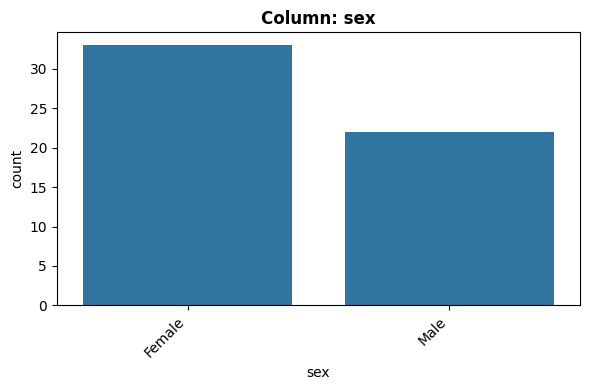

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Female' occurs 33 times (60.0%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df_long, 'sex');

/tmp/ipykernel_1397/2176211545.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


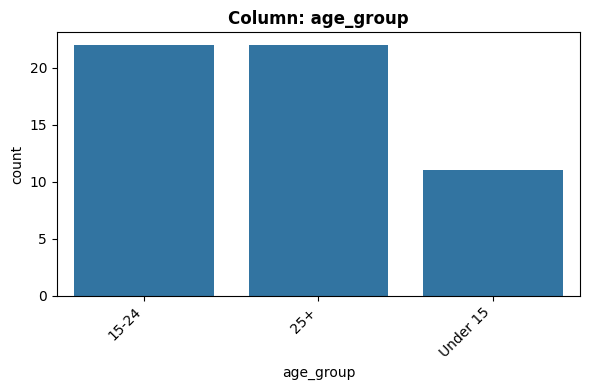

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: '15-24' occurs 22 times (40.0%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df_long, 'age_group');

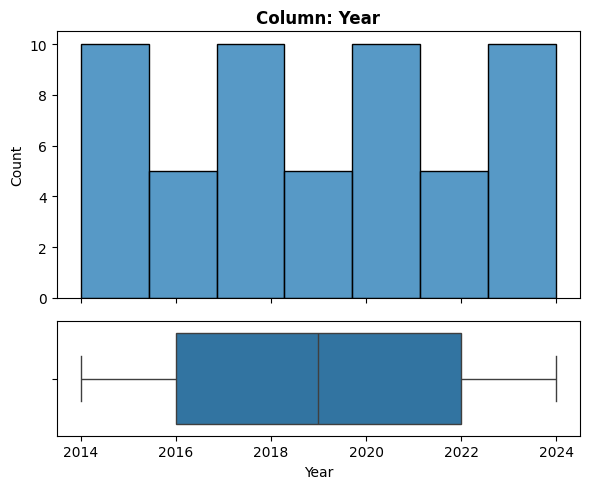

- NaN's Found: 0 (0.0%)
- Unique Values: 11
- Most common value: '2014' occurs 5 times (9.09%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df_long, 'Year');

In [ ]:
df_long.columns

Index(['country_name', 'sex', 'age_group', 'age_categories', 'Year',
       'Unemployment Rate'],
      dtype='object')

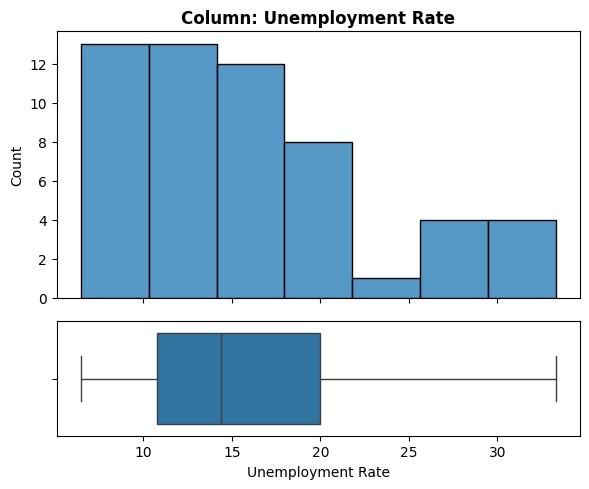

- NaN's Found: 0 (0.0%)
- Unique Values: 55
- Most common value: '13.34' occurs 1 times (1.82%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df_long, 'Unemployment Rate');

/tmp/ipykernel_1397/1688633346.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


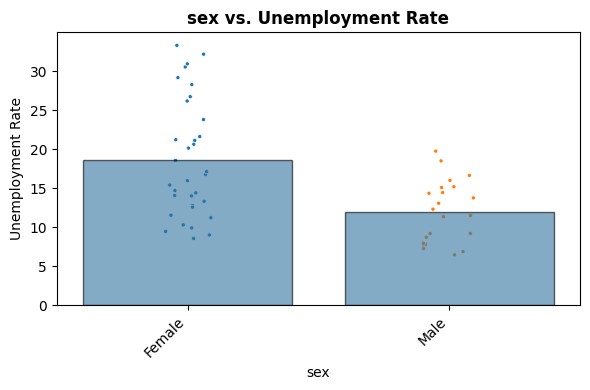

In [ ]:
plot_categorical_vs_target(df_long, 'sex');

/tmp/ipykernel_1397/1688633346.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


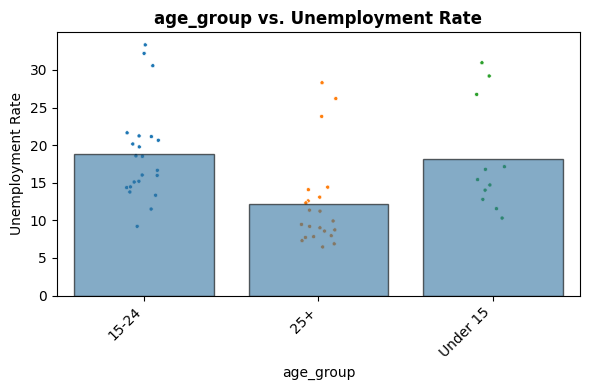

In [ ]:
plot_categorical_vs_target(df_long, 'age_group');

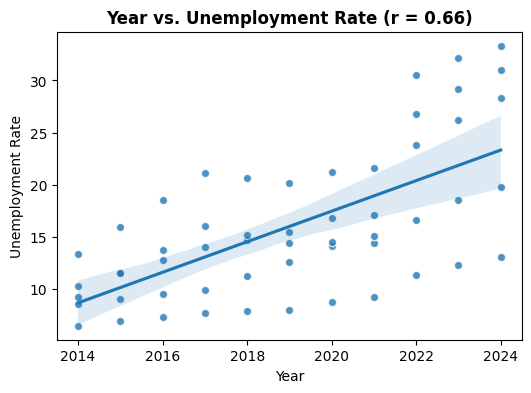

In [ ]:
plot_numeric_vs_target(df_long, 'Year');

Year and Unemployment Rate¶
Visualizations and correlation analysis show that there is no clear relationship between Year and the target variable (Unemployment Rate).
The computed Pearson correlation is very small and negative (-0.03), indicating almost no linear relationship.
This is contrary to the initial expectation of a moderate positive correlation, where one might anticipate that:
The number of graduates increases each year, and
Available job opportunities may decrease due to automation/AI impact.
Interpretation:
Despite trends in education or labor market changes, the dataset does not show a strong temporal trend in unemployment across the years included.
Year may still provide context in multivariate analysis but is not a strong predictor on its own.
Importance:
The Year feature can be included in modeling, but one should not rely solely on it to explain unemployment variations.
It is more useful for visualizing temporal trends than for predictive power in this dataset.
Dataset Overview
Dataset contains unemployment rates across countries, years (2014–2024), age groups, and gender.

Feature Summary & Modeling Advice
Feature	Type	Importance / Insights
Gender	Categorical	Slight differences in unemployment → include in modeling
Age Group	Categorical	Strong influence on target → include
Year	Numeric / Categorical	Weak predictor → include for trend context
Country	Categorical	Can be aggregated by region for analysis
Unemployment Rate	Numeric	Target variable for regression/analysis
Categorical features (Gender, Age Group, Country) may need encoding for modeling.
Numerical features (Year) can be included, but check correlations and scale if necessary.
Outliers and extreme values should be noted before modeling.
Key Insights
Young adults (15–24) face the highest unemployment rates.
Females experience slightly higher unemployment rates than males on average.
No clear year trend, despite expectations of increasing graduates or AI impact.
Missing data is minimal and localized, so it does not bias overall analysis.